<a href="https://colab.research.google.com/github/mmccoy3197/ML_Assignment_2/blob/main/dogs_cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, cv2, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
import time
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import itertools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
from pathlib import Path
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import io
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from numpy import asarray
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, cross_val_score

from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout

from sklearn.utils import shuffle

!pip install sklearn
import sklearn
from sklearn.model_selection import train_test_split

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
train_data = '/content/drive/MyDrive/dogs/train/'
test_data = '/content/drive/MyDrive/dogs/test/'

Mounted at /content/drive


*italicized text*#Conduct EDA.


In [ ]:
#look at the shape of the data and files vs categories
files = os.listdir(train_data)
category = []
for file in files:
    category_name = file.split(".")[0] # Split the individual filename
    if category_name == 'dog':
        category.append(1)
    else:
        category.append(0)

dogs = pd.DataFrame({
    'file':files, # Use the list of files
    'category':category
})


In [ ]:
print(dogs.head(),"\n--------\n",dogs.tail())

           file  category
0  cat.9115.jpg         0
1  cat.9106.jpg         0
2  cat.9094.jpg         0
3  cat.9103.jpg         0
4  cat.9096.jpg         0 
--------
                 file  category
25118   dog.1012.jpg         1
25119  dog.10140.jpg         1
25120  dog.10136.jpg         1
25121  dog.10113.jpg         1
25122  dog.10139.jpg         1


<Axes: xlabel='category'>

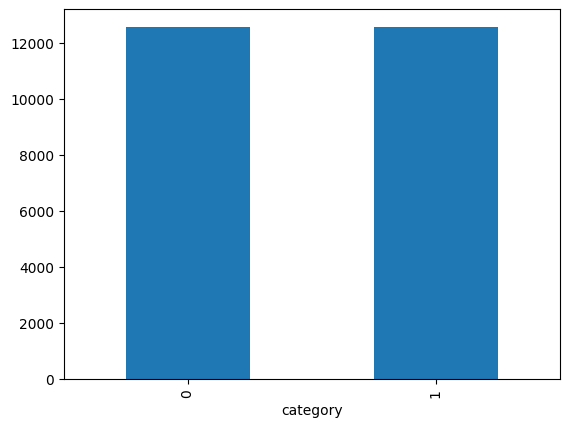

In [ ]:
dogs['category'].value_counts().plot.bar()

Visual the Data

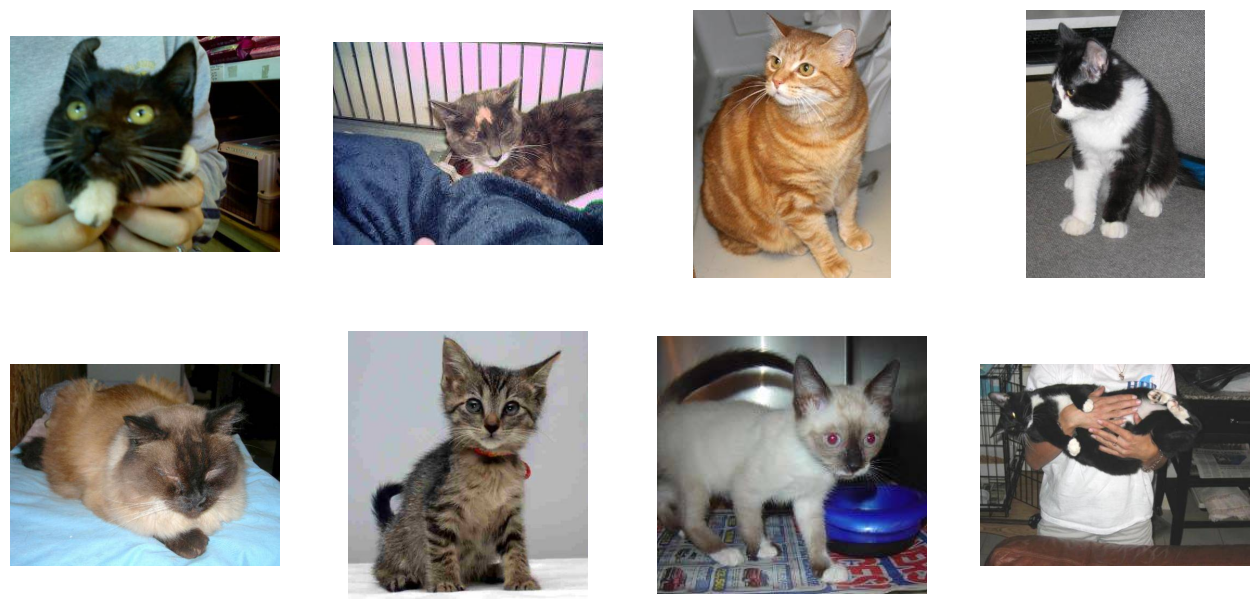

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
nrows = 4
ncols = 4

pic_index = 0

fig = plt.gcf()
fig.set_size_inches(ncols*4, nrows*4)

pic_index+=8

next_cat_pix = [os.path.join(train_data, fname)
                for fname in os.listdir(train_data)[ pic_index-8:pic_index]
               ]

for i, img_path in enumerate(next_cat_pix):
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off')

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()

Prepare the data

In [ ]:
train_images = [train_data+i for i in os.listdir(train_data)]
test_images = [test_data+i for i in os.listdir(test_data)]

ROWS = 64
COLS = 64
CHANNELS = 3

In [ ]:
def read_image(file_path):
  img = cv2.imread(file_path, cv2.IMREAD_COLOR)
  return cv2.resize(img, (ROWS, COLS), interpolation=cv2.INTER_CUBIC)

In [ ]:
def prep_data(images):
  m = len(images)
  n_x = ROWS*COLS*CHANNELS

  X = np.ndarray((m,ROWS,COLS,CHANNELS), dtype=np.uint8)
  y = np.zeros((m,1))
  print("X.shape is {}".format(X.shape))

  for i,image_file in enumerate(images) :
    image = read_image(image_file)
    X[i,:] = np.squeeze(image.reshape((ROWS, COLS, CHANNELS)))
    if 'dog' in image_file.lower() :
      y[i,0] = 1
    elif 'cat' in image_file.lower() :
      y[i,0] = 0
    else : # for test data
      y[i,0] = image_file.split('/')[-1].split('.')[0]

    if i%5000 == 0 :
      print("Proceed {} of {}".format(i, m))

  return X,y

In [ ]:
X_train, y_train = prep_data(train_images)
X_test, test_idx = prep_data(test_images)

X.shape is (25123, 64, 64, 3)
Proceed 0 of 25123
Proceed 5000 of 25123
Proceed 10000 of 25123
Proceed 15000 of 25123
Proceed 20000 of 25123
Proceed 25000 of 25123
X.shape is (12579, 64, 64, 3)
Proceed 0 of 12579
Proceed 5000 of 12579
Proceed 10000 of 12579


In [ ]:
#look at the shape of the data
print("Train shape: {}".format(X_train.shape))
print("Test shape: {}".format(X_test.shape))

Train shape: (25123, 64, 64, 3)
Test shape: (12579, 64, 64, 3)


In [ ]:
#shuffle
X_train, y_train = shuffle(X_train, y_train)

In [ ]:
#make into a binary
classes = {0: 'cats', 1: 'dogs'}

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

print("Train shape: {}".format(X_train.shape))
print("Train label shape: {}".format(y_train.shape))
print("Validation shape: {}".format(X_val.shape))
print("Validation label shape: {}".format(y_val.shape))

Train shape: (20098, 64, 64, 3)
Train label shape: (20098, 1)
Validation shape: (5025, 64, 64, 3)
Validation label shape: (5025, 1)


In [ ]:
y_train_one_hot = to_categorical(y_train)
print(y_train_one_hot.shape)

num_classes = y_train_one_hot.shape[1]
print(num_classes)

y_val_one_hot = to_categorical(y_val)
print(y_val_one_hot.shape)

(20098, 2)
2
(5025, 2)


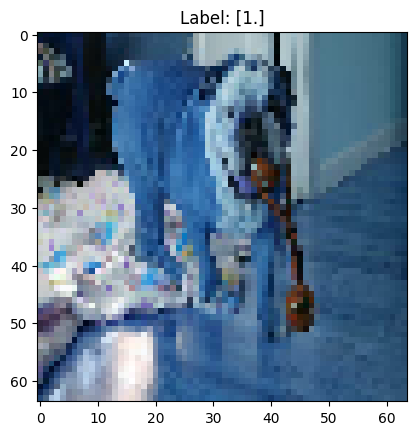

In [ ]:
def show_images(images, labels, index):
    import matplotlib.pyplot as plt
    plt.imshow(images[index])
    plt.title(f"Label: {labels[index]}")
    plt.show()
show_images(X_train, y_train, 0)

In [ ]:
#normalize
X_train_normal = X_train / 255
X_val_norm = X_val / 255

In [ ]:
#neural network with keras
model = Sequential()

model.add(Conv2D(32, (3,3), input_shape=(ROWS, COLS, CHANNELS), activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, (1,1), activation='relu'))

model.add(Flatten())
model.add(Dropout(0.4))

model.add(Dense(units=120, activation='relu'))
model.add(Dense(units=2, activation='sigmoid'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 2, 2, 512)           │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 120)                 │         245,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             242 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 766,122 (2.92 MB)

 Trainable params: 766,122 (2.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train
model.fit(X_train_normal, y_train_one_hot, validation_data=(X_val_norm, y_val_one_hot), epochs=50, batch_size = 64)

Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 178s 554ms/step - accuracy: 0.9856 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 196s 537ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 169s 537ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 203s 539ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 200s 533ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 166s 528ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 200s 522ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/50
315/315 ━━━━━

In [ ]:
#test
image = X_train[0]
test_pred = model.predict_classes(image.reshape(1, 64, 64, 3))

show_images(X_train, y_train,0)

print("Our Model Prediction: {}".format(test_pred))

AttributeError: 'Sequential' object has no attribute 'predict_classes'

In [ ]:
#testing the train model
#test
import numpy as np

image = X_train[0]
test_pred_probs = model.predict(image.reshape(1, 64, 64, 3))
test_pred = np.argmax(test_pred_probs, axis=1)

show_images(X_train, y_train,0)

print("Our Model Prediction: {}".format(test_pred))

Model #2

In [ ]:
model2 = tf.keras.models.Sequential([
    # the images were resized by ImageDataGenerator 150x150 with 3 bytes color
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    # since we have only 2 classes to predict we can use 1 neuron and sigmoid
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model2.summary()

model2.compile(optimizer=tf.keras.optimizers.RMSprop(lr=0.001),
    loss='binary_crossentropy',
    metrics = ['accuracy'])

In [ ]:
tf.keras.utils.plot_model(model2)

In [ ]:
#train
model2.fit(X_train_normal, y_train_one_hot, validation_data=(X_val_norm, y_val_one_hot), epochs=50, batch_size = 64)

Testing the model

In [ ]:
image = X_test[0]

In [ ]:
test_pred_probs2 = model2.predict(image.reshape(1, 64, 64, 3))
test_pred2 = np.argmax(test_pred_probs2, axis=1)

show_images(X_train, y_train,0)

print("Our Model Prediction: {}".format(test_pred2))

*italicized text*#Conduct EDA.


Model #3

In [ ]:
model3 = tf.keras.models.Sequential([

    # the images were resized by ImageDataGenerator 150x150 with 3 bytes color
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(512, (1,1), activation='relu')
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    # since we have only 2 classes to predict we can use 1 neuron and sigmoid
    tf.keras.layers.Dense(1, activation='sigmoid')

  ])

model3.summary()

model3.compile(optimizer=tf.keras.optimizers.RMSprop(lr=0.001),
    loss='binary_crossentropy',
    metrics = ['accuracy'])


In [ ]:
tf.keras.utils.plot_model(model3)

In [ ]:
#train
model3.fit(X_train_normal, y_train_one_hot, validation_data=(X_val_norm, y_val_one_hot), epochs=50, batch_size = 64)

Test the model

In [ ]:
test_pred_probs3 = model3.predict(image.reshape(1, 64, 64, 3))
test_pred3 = np.argmax(test_pred_probs3, axis=1)

show_images(X_test, test_idx, 0)

print("Our Model Prediction: {}".format(test_pred3))